# EDA inicial (data cruda)

## Exploración Inicial

In [232]:
import pandas as pd
# Cargar datos 
data =  pd.read_csv(r"C:\Users\rosar\RufoEsEterno\MachineLearning\TP-Machine-Learning\data\criptodataset.csv")

In [233]:
eda_data = data.copy()

In [234]:
eda_data.head()

,date,price,market_cap,volume,token,name,tvl_usd,volume_to_marketcap,price_change_%,market_cap_trend,tvl_trend,narrative
0,2024-06-01,0.021743,2.677851e+08,4.748500e+06,one,Harmony,2870121,0.017732,NaN,NaN,NaN,Desconocido
1,2024-06-02,0.021809,2.682872e+08,3.105342e+06,one,Harmony,2927085,0.011575,0.303395,0.187511,1.984725,Desconocido
2,2024-06-03,0.021625,2.661746e+08,6.740671e+06,one,Harmony,2832820,0.025324,-0.843260,-0.787463,-3.220439,Desconocido
3,2024-06-04,0.022032,2.707636e+08,6.316662e+06,one,Harmony,2929770,0.023329,1.885679,1.724051,3.422385,Desconocido
4,2024-06-05,0.022940,2.822307e+08,6.750956e+06,one,Harmony,2433359,0.023920,4.121088,4.235119,-16.943685,Desconocido


In [235]:
eda_data.describe()

,price,market_cap,volume,tvl_usd,volume_to_marketcap,price_change_%,market_cap_trend,tvl_trend
count,1740.000000,1.740000e+03,1.740000e+03,1.740000e+03,1740.000000,1735.000000,1735.000000,1735.000000
mean,0.224612,1.777126e+08,1.127639e+07,3.309387e+07,0.048381,-0.161313,-0.103440,0.339615
std,0.295149,1.808609e+08,2.096859e+07,6.502968e+07,0.057917,5.096132,5.098647,11.335973
min,0.000983,2.635667e+06,1.011485e+03,7.246400e+04,0.000199,-20.419520,-20.265189,-68.589293
25%,0.010654,9.298688e+06,1.233864e+05,3.205822e+05,0.010254,-2.721573,-2.741799,-2.811987
50%,0.016684,1.505689e+08,6.025160e+06,1.133220e+06,0.035491,-0.253257,-0.156880,0.000000
75%,0.453352,2.947722e+08,1.344001e+07,2.455542e+06,0.063734,2.098528,2.180865,2.352405
max,1.853151,7.748413e+08,3.250321e+08,2.217892e+08,0.843553,44.344404,44.223039,223.317782


In [236]:
eda_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1740 entries, 0 to 1739
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   date                 1740 non-null   object 
 1   price                1740 non-null   float64
 2   market_cap           1740 non-null   float64
 3   volume               1740 non-null   float64
 4   token                1740 non-null   object 
 5   name                 1740 non-null   object 
 6   tvl_usd              1740 non-null   int64  
 7   volume_to_marketcap  1740 non-null   float64
 8   price_change_%       1735 non-null   float64
 9   market_cap_trend     1735 non-null   float64
 10  tvl_trend            1735 non-null   float64
 11  narrative            1740 non-null   object 
dtypes: float64(7), int64(1), object(4)
memory usage: 163.2+ KB


## Verificacion de valores nulos y duplicados

In [237]:

print(eda_data.isnull().sum())

date                   0
price                  0
market_cap             0
volume                 0
token                  0
name                   0
tvl_usd                0
volume_to_marketcap    0
price_change_%         5
market_cap_trend       5
tvl_trend              5
narrative              0
dtype: int64


In [238]:
'''
Los nulos de son los primeros registros de cada token por lo que los vamos a dropear 
'''

# Eliminar esas 5 filas nulas (no afecta la calidad del dataset)
# eda_data = eda_data.dropna(subset=["price_change_%", "market_cap_trend", "tvl_trend"])
eda_data = eda_data.fillna(0)


In [239]:
print(eda_data.isnull().sum())

date                   0
price                  0
market_cap             0
volume                 0
token                  0
name                   0
tvl_usd                0
volume_to_marketcap    0
price_change_%         0
market_cap_trend       0
tvl_trend              0
narrative              0
dtype: int64


In [240]:
print(eda_data.duplicated().sum())

0


In [241]:
'''
Borramos la columna narrative ya que no aporta nada al modelo
todos los valores son "desconocido"
'''

eda_data.drop(columns=["narrative"],inplace=True)

In [242]:
eda_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1740 entries, 0 to 1739
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   date                 1740 non-null   object 
 1   price                1740 non-null   float64
 2   market_cap           1740 non-null   float64
 3   volume               1740 non-null   float64
 4   token                1740 non-null   object 
 5   name                 1740 non-null   object 
 6   tvl_usd              1740 non-null   int64  
 7   volume_to_marketcap  1740 non-null   float64
 8   price_change_%       1740 non-null   float64
 9   market_cap_trend     1740 non-null   float64
 10  tvl_trend            1740 non-null   float64
dtypes: float64(7), int64(1), object(3)
memory usage: 149.7+ KB


## Distribucíon de variables numéricas por cada token

In [243]:
import seaborn as sns
import matplotlib.pyplot as plt

In [244]:
numeric_columns = eda_data.select_dtypes(include='number').columns

In [245]:
from scipy.stats import skew, kurtosis, shapiro

In [246]:
def plot_numeric_distributions(data, numeric_cols):  
    cols_per_row = 2
    n = len(numeric_cols)
    rows = -(-n // cols_per_row)  

    plt.figure(figsize=(cols_per_row * 7, rows * 4))

    for idx, col in enumerate(numeric_cols, 1):
        sk = skew(data[col].dropna())
        kt = kurtosis(data[col].dropna())
        _, p = shapiro(data[col].dropna())

        plt.subplot(rows, cols_per_row*2, idx*2-1)
        sns.histplot(data[col], kde=True, bins=20, color="skyblue")
        plt.title(f"{col}\nSkew: {sk:.2f}, Kurt: {kt:.2f}, p={p:.2g}")

        plt.subplot(rows, cols_per_row*2, idx*2)
        sns.boxplot(x=data[col], color="lightcoral")
        plt.title(f"{col} - Boxplot")

    plt.tight_layout()
    plt.show()

### Distribución de variables numéricas para Harmony


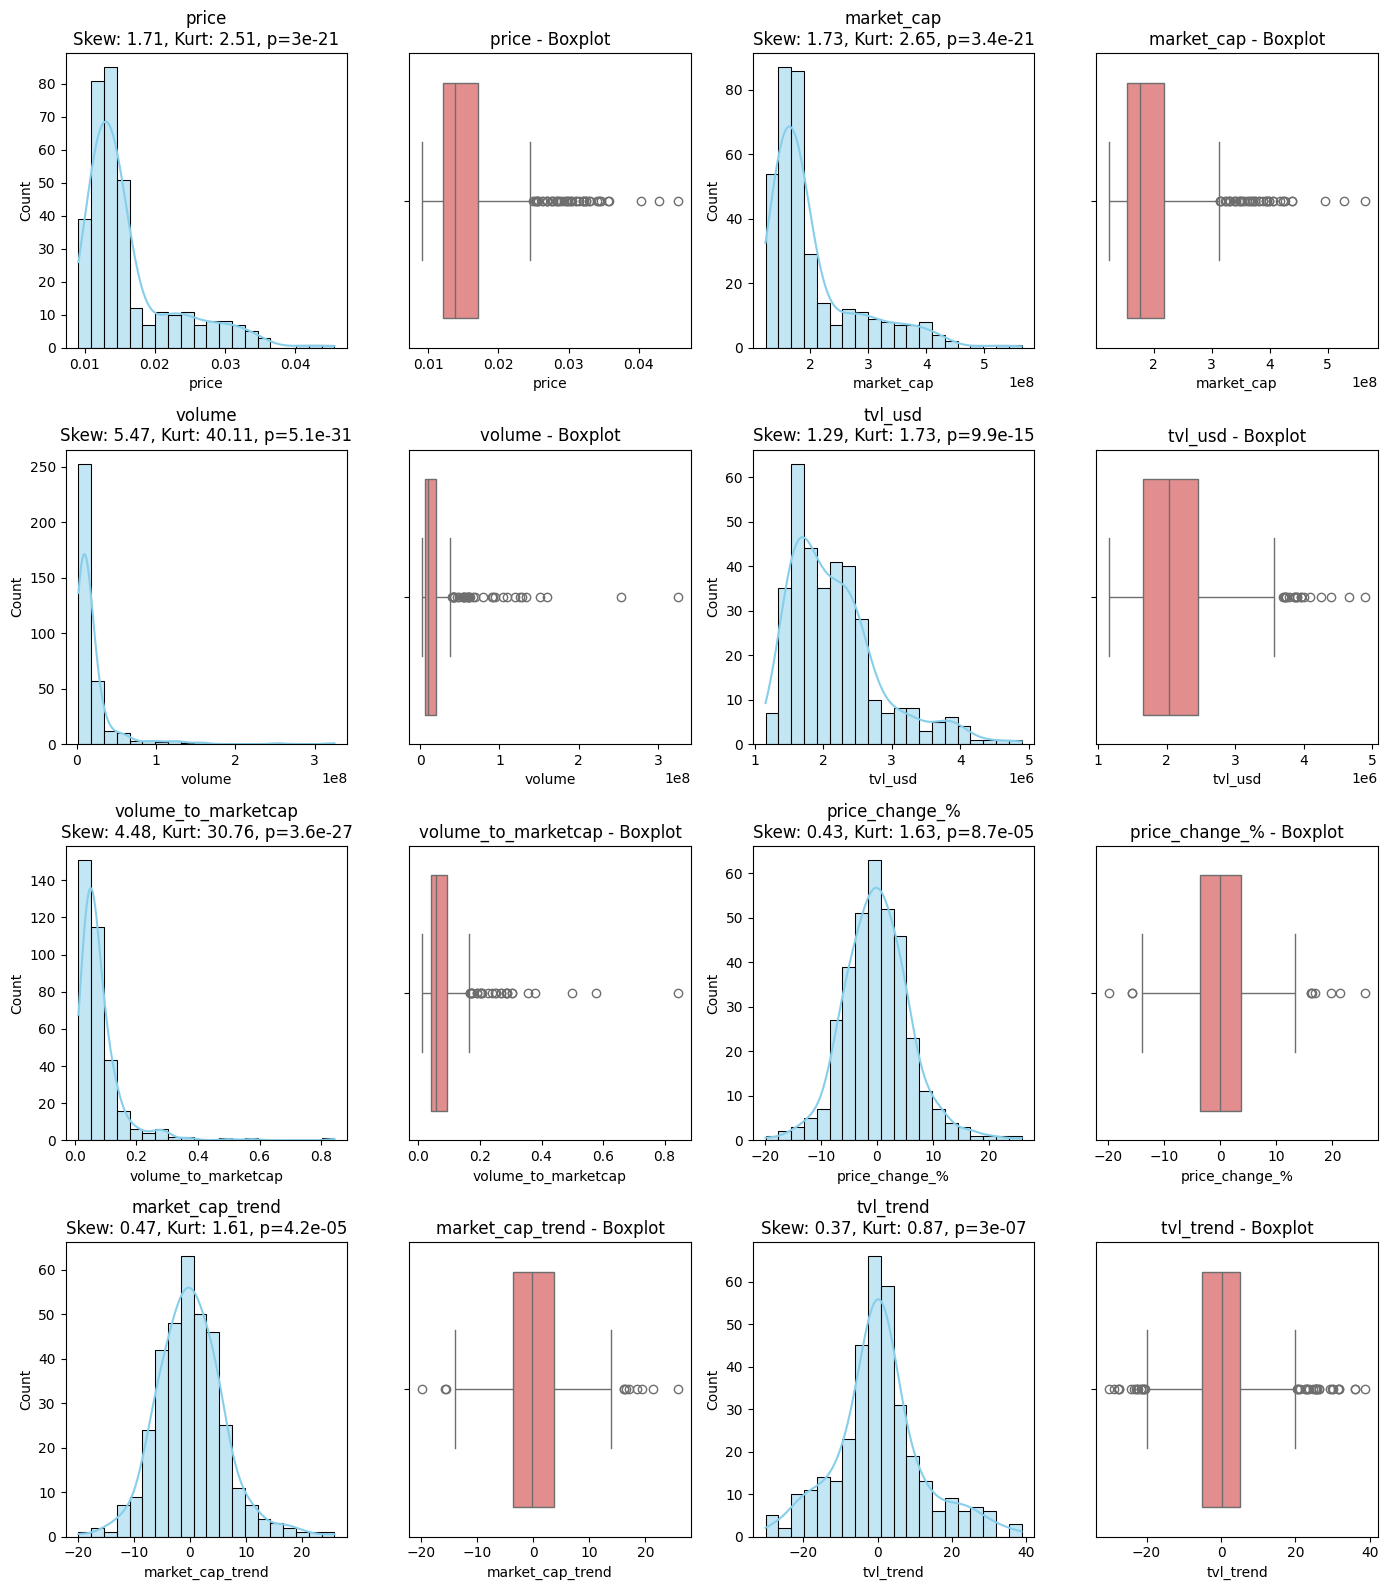

### Distribución de variables numéricas para Kadena


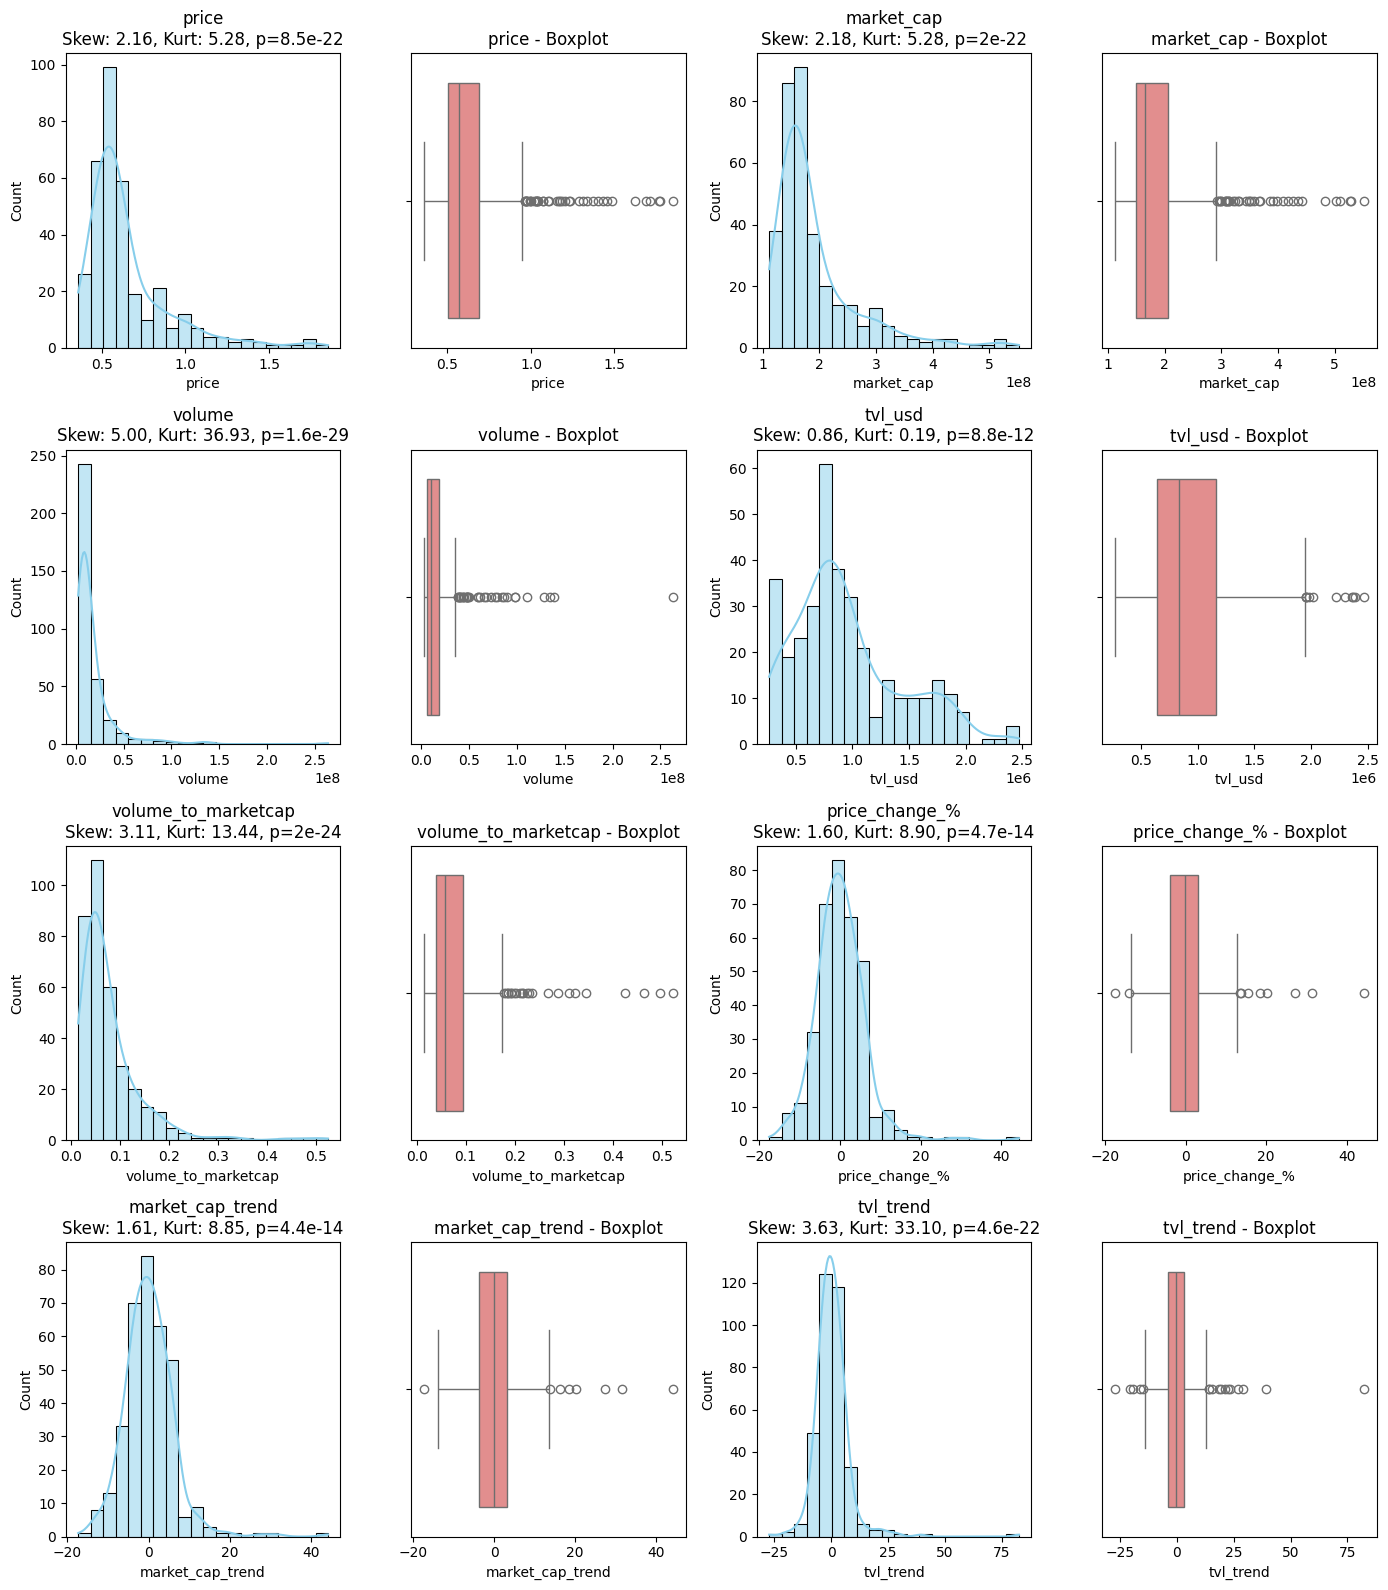

### Distribución de variables numéricas para Kava


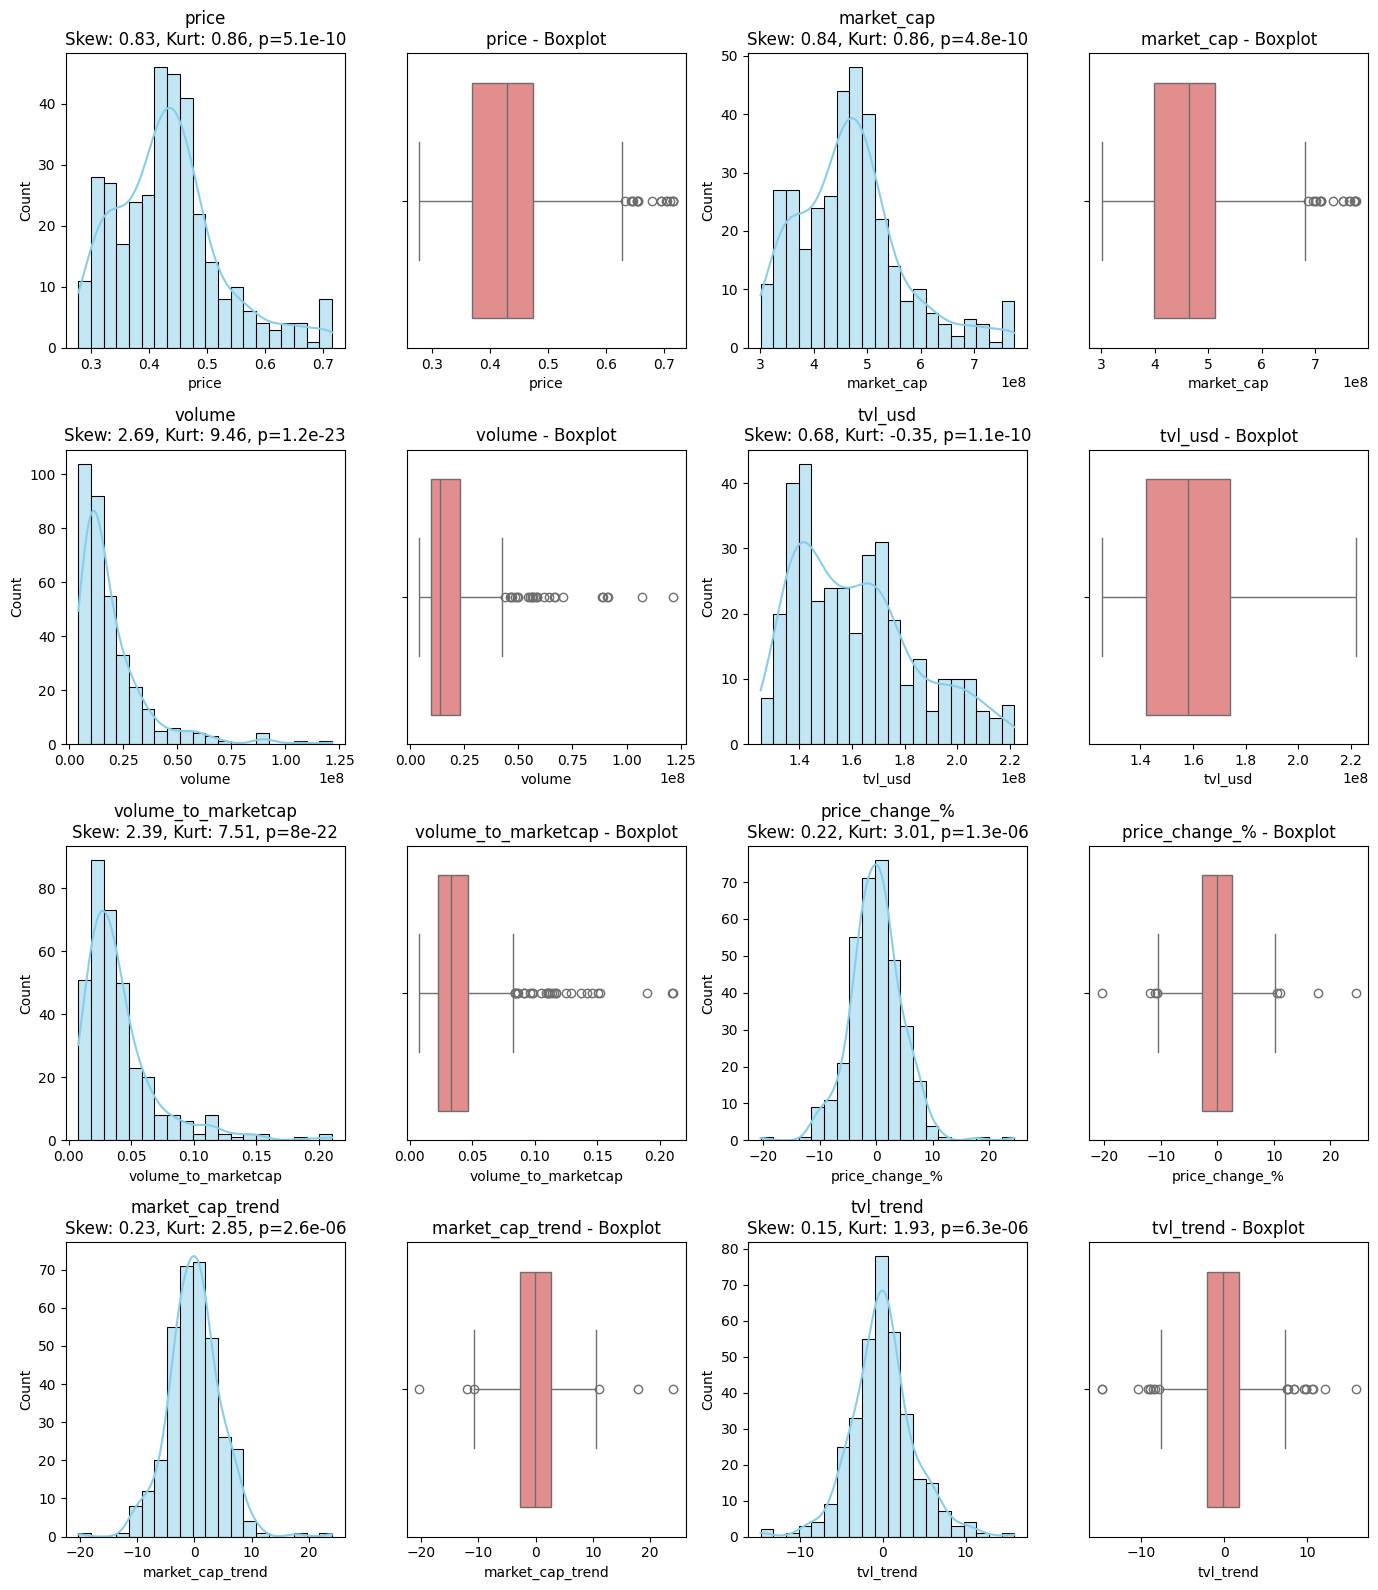

### Distribución de variables numéricas para Nolus


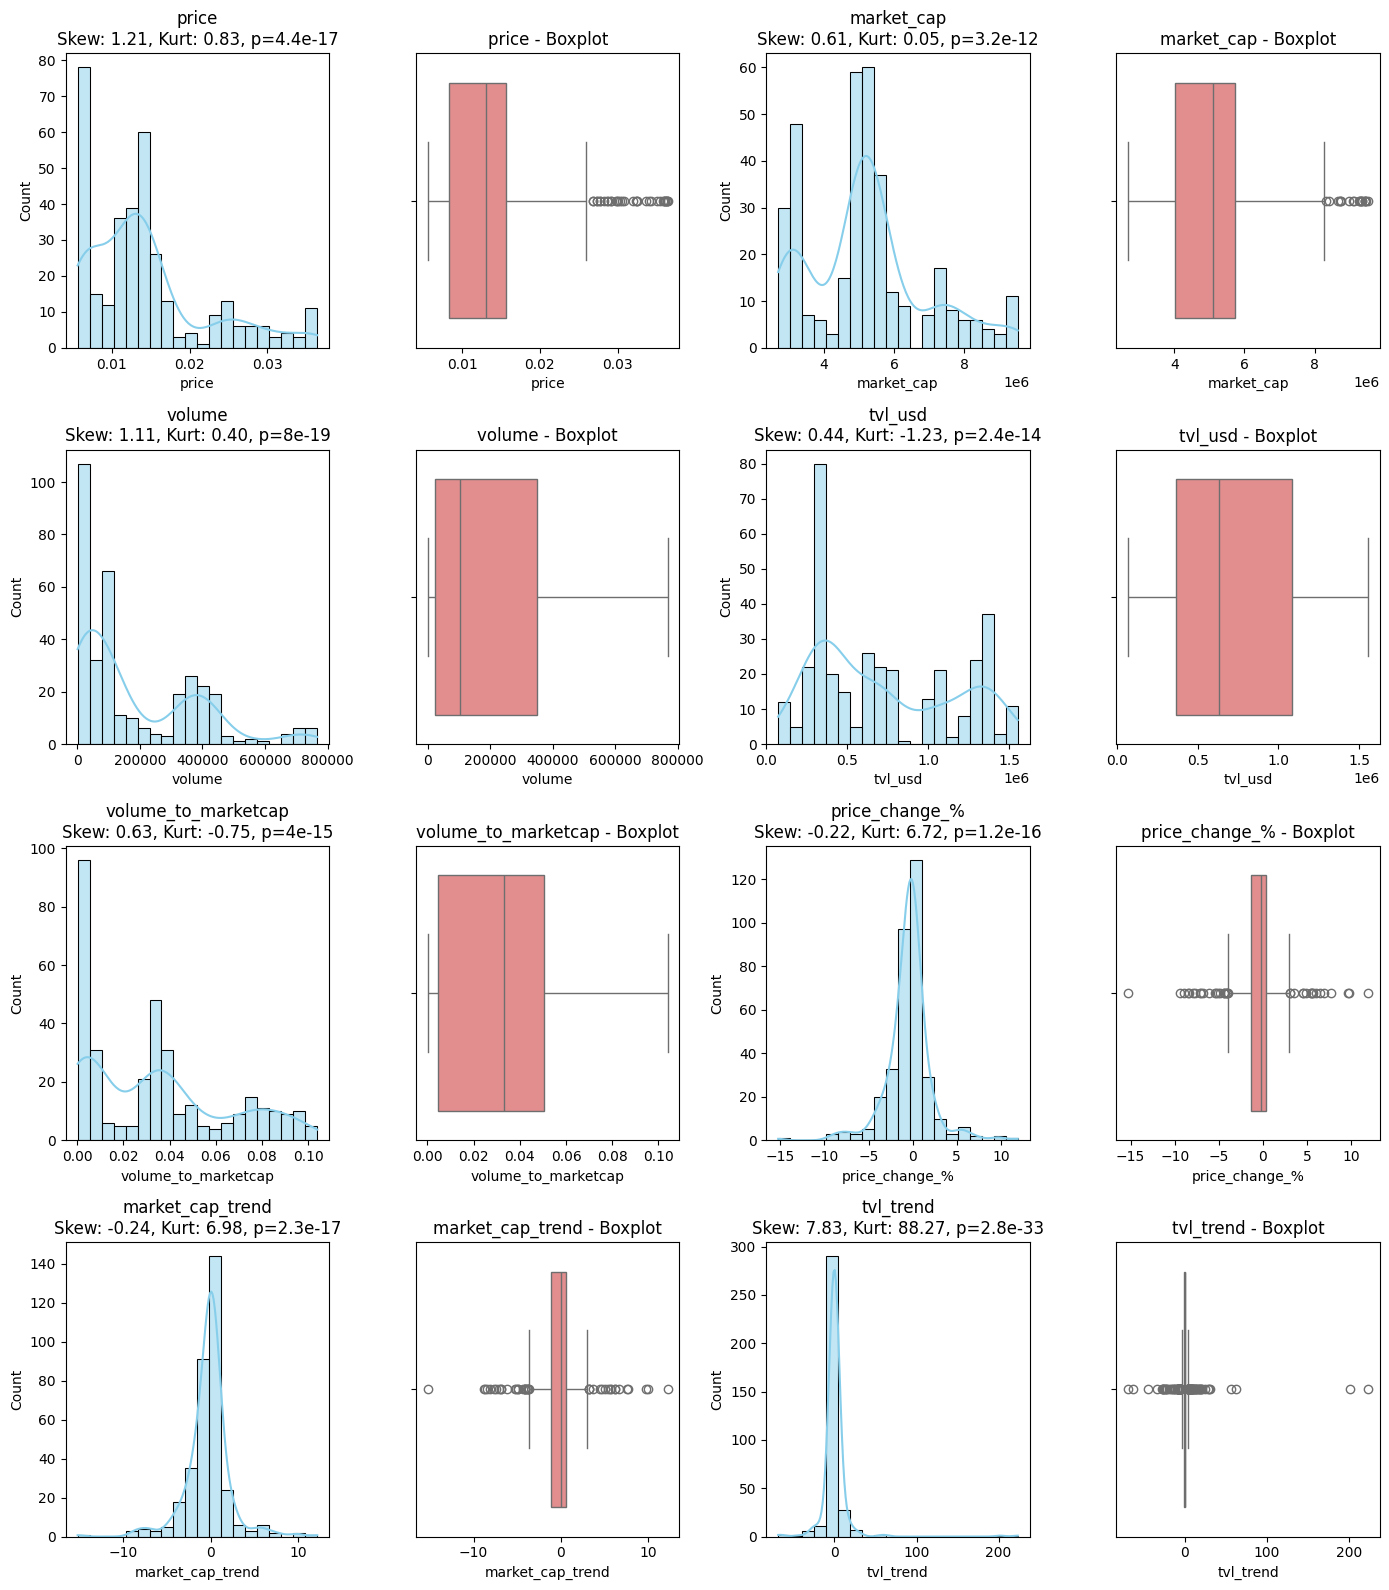

### Distribución de variables numéricas para Stargaze


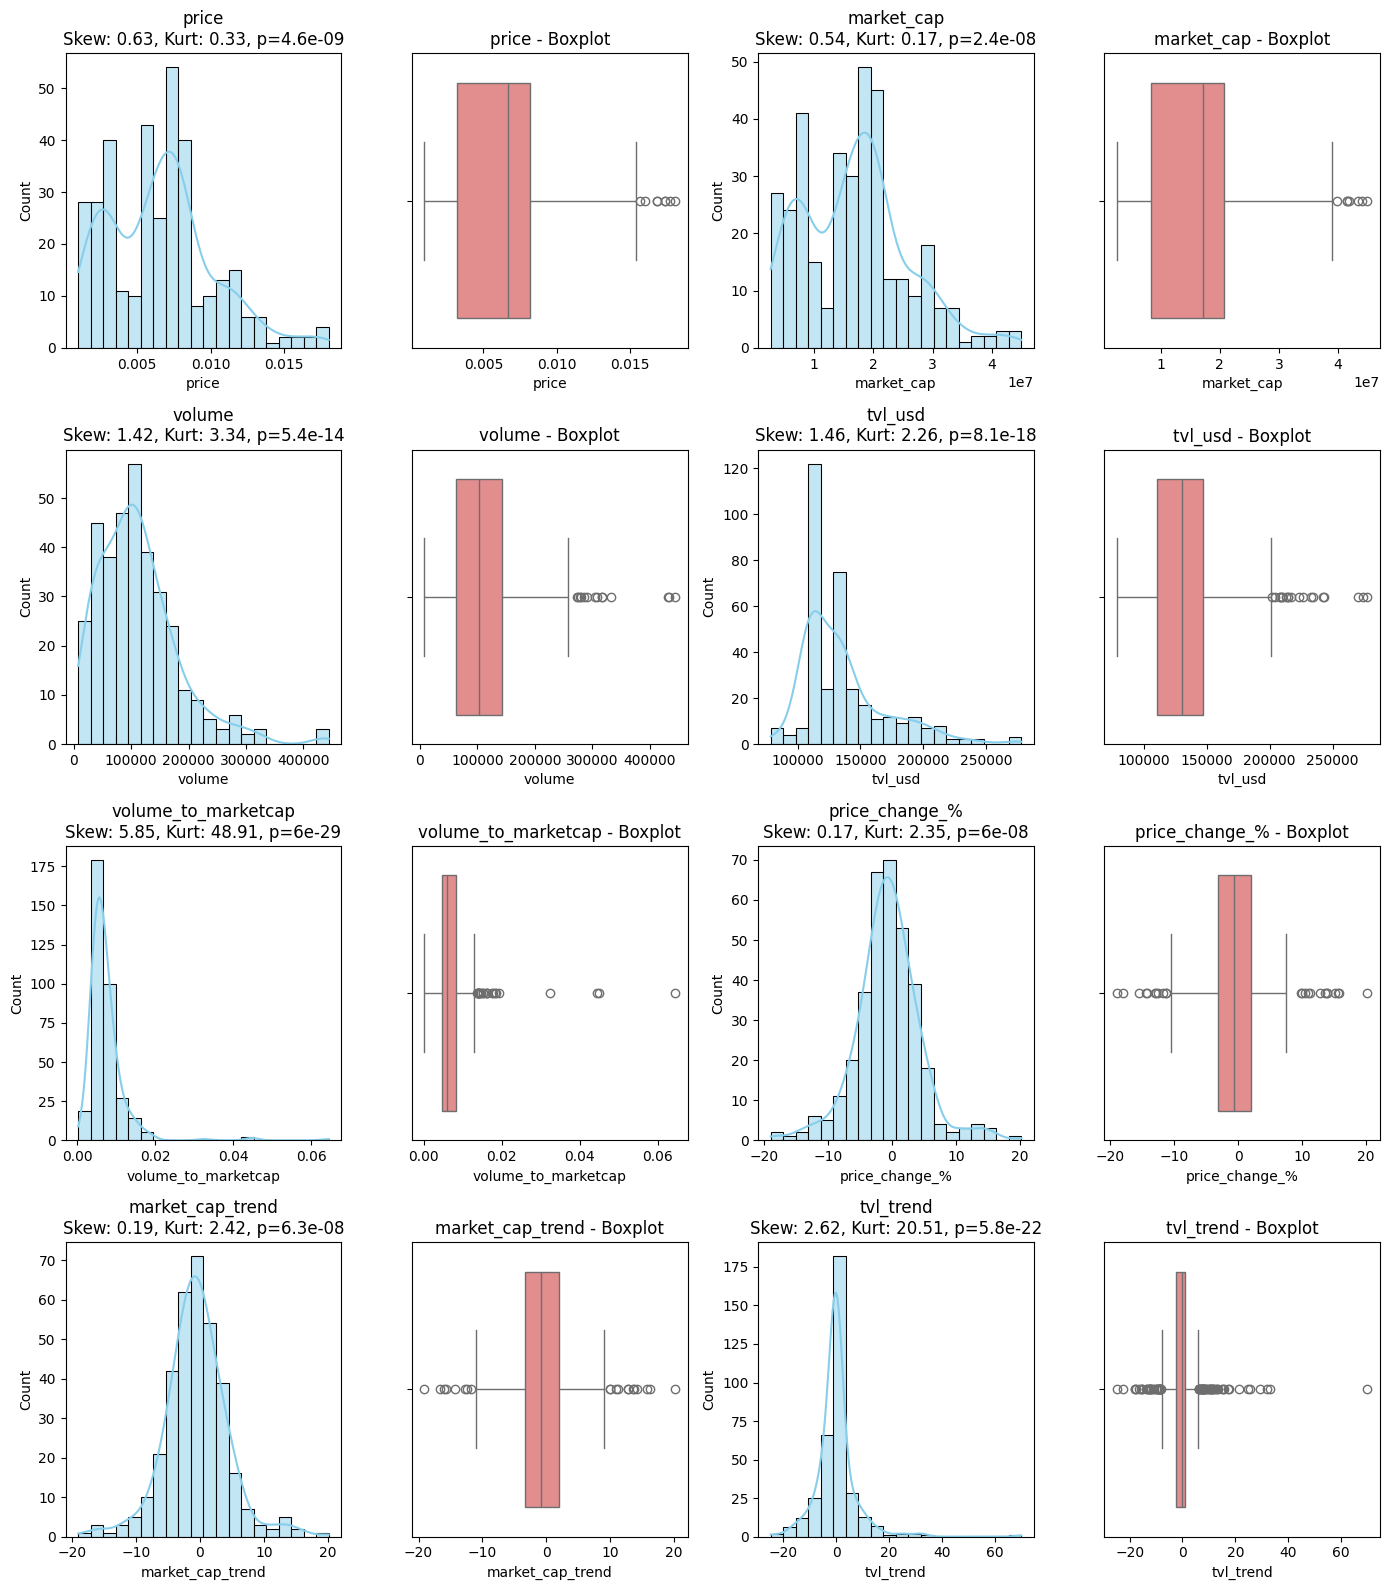

In [247]:
token_name = eda_data["name"].unique()
for token in token_name:
    print(f"### Distribución de variables numéricas para {token}")
    token_data = eda_data[eda_data["name"] == token]
    plot_numeric_distributions(token_data, numeric_columns)


Análisis de la distribución de variables numéticas:

Moneda Harmony:

price: Posee una alta asimetría positiva, una kurtosis medianamente alta, así como un pvalue muchísimos menor a 0.05. Esto lo podemos observar en el histograma puesto a que los bins son mas altos en los valores más bajos y la cola está a la derecha, por otro lado, la concentración es mucho mayor en el extremo izquierdo a comparación del derecho donde la cola es ligera, es por ello que nuestra kurtosis se acerca a 3.

market_cap: ...

Por lo tanto en la fase de preprocesamiento se realizarán transformaciones logarítmicas y suavizado de outliers para contrarestar la asimetría fuerte y las colas pesadas

## Deteccion de outliers estacionales

In [248]:
# Revisar las columnas disponibles para identificar información temporal
print("Columnas disponibles:")
print(eda_data.columns.tolist())
print("\nTipos de datos:")
print(eda_data.dtypes)

Columnas disponibles:
['date', 'price', 'market_cap', 'volume', 'token', 'name', 'tvl_usd', 'volume_to_marketcap', 'price_change_%', 'market_cap_trend', 'tvl_trend']

Tipos de datos:
date                    object
price                  float64
market_cap             float64
volume                 float64
token                   object
name                    object
tvl_usd                  int64
volume_to_marketcap    float64
price_change_%         float64
market_cap_trend       float64
tvl_trend              float64
dtype: object


In [249]:
# Convertir la columna date a datetime
eda_data['date'] = pd.to_datetime(eda_data['date'])

# Examinar el rango temporal
print(f"Rango temporal del dataset:")
print(f"Fecha inicial: {eda_data['date'].min()}")
print(f"Fecha final: {eda_data['date'].max()}")
print(f"Total de días: {(eda_data['date'].max() - eda_data['date'].min()).days}")

# Crear columnas auxiliares para el análisis temporal
eda_data['year'] = eda_data['date'].dt.year
eda_data['month'] = eda_data['date'].dt.month
eda_data['quarter'] = eda_data['date'].dt.quarter
eda_data['month_name'] = eda_data['date'].dt.strftime('%B')

print(f"\nAños disponibles: {sorted(eda_data['year'].unique())}")
print(f"Meses disponibles: {sorted(eda_data['month'].unique())}")
print(f"Trimestres disponibles: {sorted(eda_data['quarter'].unique())}")

Rango temporal del dataset:
Fecha inicial: 2024-06-01 00:00:00
Fecha final: 2025-05-14 00:00:00
Total de días: 347

Años disponibles: [np.int32(2024), np.int32(2025)]
Meses disponibles: [np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12)]
Trimestres disponibles: [np.int32(1), np.int32(2), np.int32(3), np.int32(4)]


In [250]:
def detect_outliers_iqr(data, column):
    """
    Detecta outliers usando el método IQR (Rango Intercuartílico)
    """
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    
    # Límites para outliers
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Identificar outliers
    outliers_mask = (data[column] < lower_bound) | (data[column] > upper_bound)
    
    return outliers_mask, lower_bound, upper_bound

def analyze_seasonal_outliers(data, numeric_columns, method='iqr'):
    """
    Analiza la estacionalidad de outliers para todas las variables numéricas
    """
    results = {}
    
    for column in numeric_columns:
        if column in ['year', 'month', 'quarter']:  # Excluir columnas temporales
            continue
            
        print(f"\n=== Análisis de outliers para: {column} ===")
        
        # Detectar outliers
        outliers_mask, lower_bound, upper_bound = detect_outliers_iqr(data, column)
        outliers_data = data[outliers_mask].copy()
        
        print(f"Total de outliers detectados: {len(outliers_data)}")
        print(f"Porcentaje de outliers: {len(outliers_data)/len(data)*100:.2f}%")
        
        if len(outliers_data) == 0:
            print("No se detectaron outliers para esta variable.")
            continue
            
        # Análisis mensual
        monthly_counts = outliers_data['month'].value_counts().sort_index()
        total_outliers = len(outliers_data)
        monthly_percentages = (monthly_counts / total_outliers * 100).round(2)
        
        # Análisis trimestral
        quarterly_counts = outliers_data['quarter'].value_counts().sort_index()
        quarterly_percentages = (quarterly_counts / total_outliers * 100).round(2)
        
        # Determinar estacionalidad
        max_monthly_percentage = monthly_percentages.max()
        max_quarterly_percentage = quarterly_percentages.max()
        
        is_seasonal_monthly = max_monthly_percentage >= 30
        is_seasonal_quarterly = max_quarterly_percentage >= 40
        
        # Identificar período dominante
        dominant_month = monthly_percentages.idxmax()
        dominant_quarter = quarterly_percentages.idxmax()
        
        # Mapear números de mes a nombres
        month_names = {1: 'Enero', 2: 'Febrero', 3: 'Marzo', 4: 'Abril', 
                      5: 'Mayo', 6: 'Junio', 7: 'Julio', 8: 'Agosto',
                      9: 'Septiembre', 10: 'Octubre', 11: 'Noviembre', 12: 'Diciembre'}
        
        print(f"\n--- Distribución mensual de outliers ---")
        for month, count in monthly_counts.items():
            percentage = monthly_percentages[month]
            print(f"{month_names[month]}: {count} outliers ({percentage}%)")
        
        print(f"\n--- Distribución trimestral de outliers ---")
        for quarter, count in quarterly_counts.items():
            percentage = quarterly_percentages[quarter]
            print(f"Trimestre {quarter}: {count} outliers ({percentage}%)")
        
        print(f"\n--- Análisis de estacionalidad ---")
        print(f"Mes con mayor concentración: {month_names[dominant_month]} ({max_monthly_percentage}%)")
        print(f"¿Estacional por mes? {is_seasonal_monthly} (umbral: ≥30%)")
        print(f"Trimestre con mayor concentración: {dominant_quarter} ({max_quarterly_percentage}%)")
        print(f"¿Estacional por trimestre? {is_seasonal_quarterly} (umbral: ≥40%)")
        
        # Guardar resultados
        results[column] = {
            'outliers_count': total_outliers,
            'outliers_percentage': len(outliers_data)/len(data)*100,
            'monthly_distribution': monthly_counts.to_dict(),
            'monthly_percentages': monthly_percentages.to_dict(),
            'quarterly_distribution': quarterly_counts.to_dict(),
            'quarterly_percentages': quarterly_percentages.to_dict(),
            'dominant_month': dominant_month,
            'dominant_quarter': dominant_quarter,
            'max_monthly_percentage': max_monthly_percentage,
            'max_quarterly_percentage': max_quarterly_percentage,
            'is_seasonal_monthly': is_seasonal_monthly,
            'is_seasonal_quarterly': is_seasonal_quarterly,
            'is_seasonal': is_seasonal_monthly or is_seasonal_quarterly,
            'outliers_indices': outliers_data.index.tolist(),
            'bounds': {'lower': lower_bound, 'upper': upper_bound}
        }
    
    return results

# Definir las variables numéricas a analizar (excluyendo las temporales)
variables_to_analyze = ['price', 'market_cap', 'volume', 'tvl_usd', 
                       'volume_to_marketcap', 'price_change_%', 'market_cap_trend', 'tvl_trend']



In [251]:
# Ejecutar el análisis de estacionalidad
seasonal_analysis_results = analyze_seasonal_outliers(eda_data, variables_to_analyze)


=== Análisis de outliers para: price ===
Total de outliers detectados: 21
Porcentaje de outliers: 1.21%

--- Distribución mensual de outliers ---
Noviembre: 3 outliers (14.29%)
Diciembre: 18 outliers (85.71%)

--- Distribución trimestral de outliers ---
Trimestre 4: 21 outliers (100.0%)

--- Análisis de estacionalidad ---
Mes con mayor concentración: Diciembre (85.71%)
¿Estacional por mes? True (umbral: ≥30%)
Trimestre con mayor concentración: 4 (100.0%)
¿Estacional por trimestre? True (umbral: ≥40%)

=== Análisis de outliers para: market_cap ===
Total de outliers detectados: 9
Porcentaje de outliers: 0.52%

--- Distribución mensual de outliers ---
Junio: 3 outliers (33.33%)
Diciembre: 6 outliers (66.67%)

--- Distribución trimestral de outliers ---
Trimestre 2: 3 outliers (33.33%)
Trimestre 4: 6 outliers (66.67%)

--- Análisis de estacionalidad ---
Mes con mayor concentración: Diciembre (66.67%)
¿Estacional por mes? True (umbral: ≥30%)
Trimestre con mayor concentración: 4 (66.67%)
¿E

In [ ]:
print("total de outliears en el dataset:")

In [252]:
# Resumen general de distribución de outliers
print("\n" + "="*80)
print("RESUMEN GENERAL DE DISTRIBUCIÓN DE OUTLIERS")
print("="*80)

# Mapear números de mes a nombres
month_names = {1: 'Enero', 2: 'Febrero', 3: 'Marzo', 4: 'Abril', 
              5: 'Mayo', 6: 'Junio', 7: 'Julio', 8: 'Agosto',
              9: 'Septiembre', 10: 'Octubre', 11: 'Noviembre', 12: 'Diciembre'}

# Compilar todos los outliers de todas las variables
all_outliers_monthly = {}
all_outliers_quarterly = {}
total_outliers_count = 0
seasonal_variables = []

for var, result in seasonal_analysis_results.items():
    total_outliers_count += result['outliers_count']
    
    # Sumar outliers por mes
    for month, count in result['monthly_distribution'].items():
        all_outliers_monthly[month] = all_outliers_monthly.get(month, 0) + count
    
    # Sumar outliers por trimestre
    for quarter, count in result['quarterly_distribution'].items():
        all_outliers_quarterly[quarter] = all_outliers_quarterly.get(quarter, 0) + count
    
    # Identificar variables estacionales
    if result['is_seasonal']:
        seasonal_variables.append(var)

# Calcular porcentajes generales
monthly_percentages = {month: (count / total_outliers_count * 100) for month, count in all_outliers_monthly.items()}
quarterly_percentages = {quarter: (count / total_outliers_count * 100) for quarter, count in all_outliers_quarterly.items()}

print(f"Total de outliers detectados: {total_outliers_count}")
print(f"Variables analizadas: {len(seasonal_analysis_results)}")

print(f"\nDISTRIBUCIÓN MENSUAL DE OUTLIERS:")
for month in range(1, 13):
    count = all_outliers_monthly.get(month, 0)
    percentage = monthly_percentages.get(month, 0)
    if count > 0:
        status = "*" if percentage >= 30 else " "
        print(f"  {status} {month_names[month]:12}: {count:4d} outliers ({percentage:5.1f}%)")

print(f"\nDISTRIBUCIÓN TRIMESTRAL DE OUTLIERS:")
for quarter in range(1, 5):
    count = all_outliers_quarterly.get(quarter, 0)
    percentage = quarterly_percentages.get(quarter, 0)
    if count > 0:
        status = "*" if percentage >= 40 else " "
        print(f"  {status} Trimestre {quarter}: {count:4d} outliers ({percentage:5.1f}%)")

# Determinar estacionalidad general
max_monthly_percentage = max(monthly_percentages.values()) if monthly_percentages else 0
max_quarterly_percentage = max(quarterly_percentages.values()) if quarterly_percentages else 0

print(f"\n{'='*80}")
print(f"ANÁLISIS DE ESTACIONALIDAD")
print(f"{'='*80}")
print(f"Variables con estacionalidad individual: {len(seasonal_variables)}")
print(f"Concentración mensual máxima: {max_monthly_percentage:.1f}%")
print(f"Concentración trimestral máxima: {max_quarterly_percentage:.1f}%")

is_seasonal_general = max_monthly_percentage >= 30 or max_quarterly_percentage >= 40

if is_seasonal_general:
    print(f"\nRECOMENDAGIÓN: DIVIDIR EL DATASET")
    print(f"Se detectó concentración estacional significativa en los outliers.")
    
    if max_monthly_percentage >= 30:
        dominant_month = max(monthly_percentages, key=monthly_percentages.get)
        print(f"Mes con mayor concentración: {month_names[dominant_month]} ({max_monthly_percentage:.1f}%)")
    
    if max_quarterly_percentage >= 40:
        dominant_quarter = max(quarterly_percentages, key=quarterly_percentages.get)
        print(f"Trimestre con mayor concentración: Q{dominant_quarter} ({max_quarterly_percentage:.1f}%)")
else:
    print(f"\nRECOMENDAGIÓN: NO DIVIDIR EL DATASET")
    print(f"No se detectó concentración estacional significativa.")

print(f"\nUmbrales utilizados: Mensual ≥30% | Trimestral ≥40%")
print(f"* = Supera el umbral de estacionalidad")


RESUMEN GENERAL DE DISTRIBUCIÓN DE OUTLIERS
Total de outliers detectados: 1013
Variables analizadas: 8

DISTRIBUCIÓN MENSUAL DE OUTLIERS:
    Enero       :  102 outliers ( 10.1%)
    Febrero     :   77 outliers (  7.6%)
    Marzo       :   62 outliers (  6.1%)
    Abril       :   66 outliers (  6.5%)
    Mayo        :   38 outliers (  3.8%)
    Junio       :   77 outliers (  7.6%)
    Julio       :   65 outliers (  6.4%)
    Agosto      :   65 outliers (  6.4%)
    Septiembre  :   57 outliers (  5.6%)
    Octubre     :   57 outliers (  5.6%)
    Noviembre   :  150 outliers ( 14.8%)
    Diciembre   :  197 outliers ( 19.4%)

DISTRIBUCIÓN TRIMESTRAL DE OUTLIERS:
    Trimestre 1:  241 outliers ( 23.8%)
    Trimestre 2:  181 outliers ( 17.9%)
    Trimestre 3:  187 outliers ( 18.5%)
    Trimestre 4:  404 outliers ( 39.9%)

ANÁLISIS DE ESTACIONALIDAD
Variables con estacionalidad individual: 4
Concentración mensual máxima: 19.4%
Concentración trimestral máxima: 39.9%

RECOMENDAGIÓN: NO DIVIDI

Creando visualizaciones de distribución temporal de outliers...


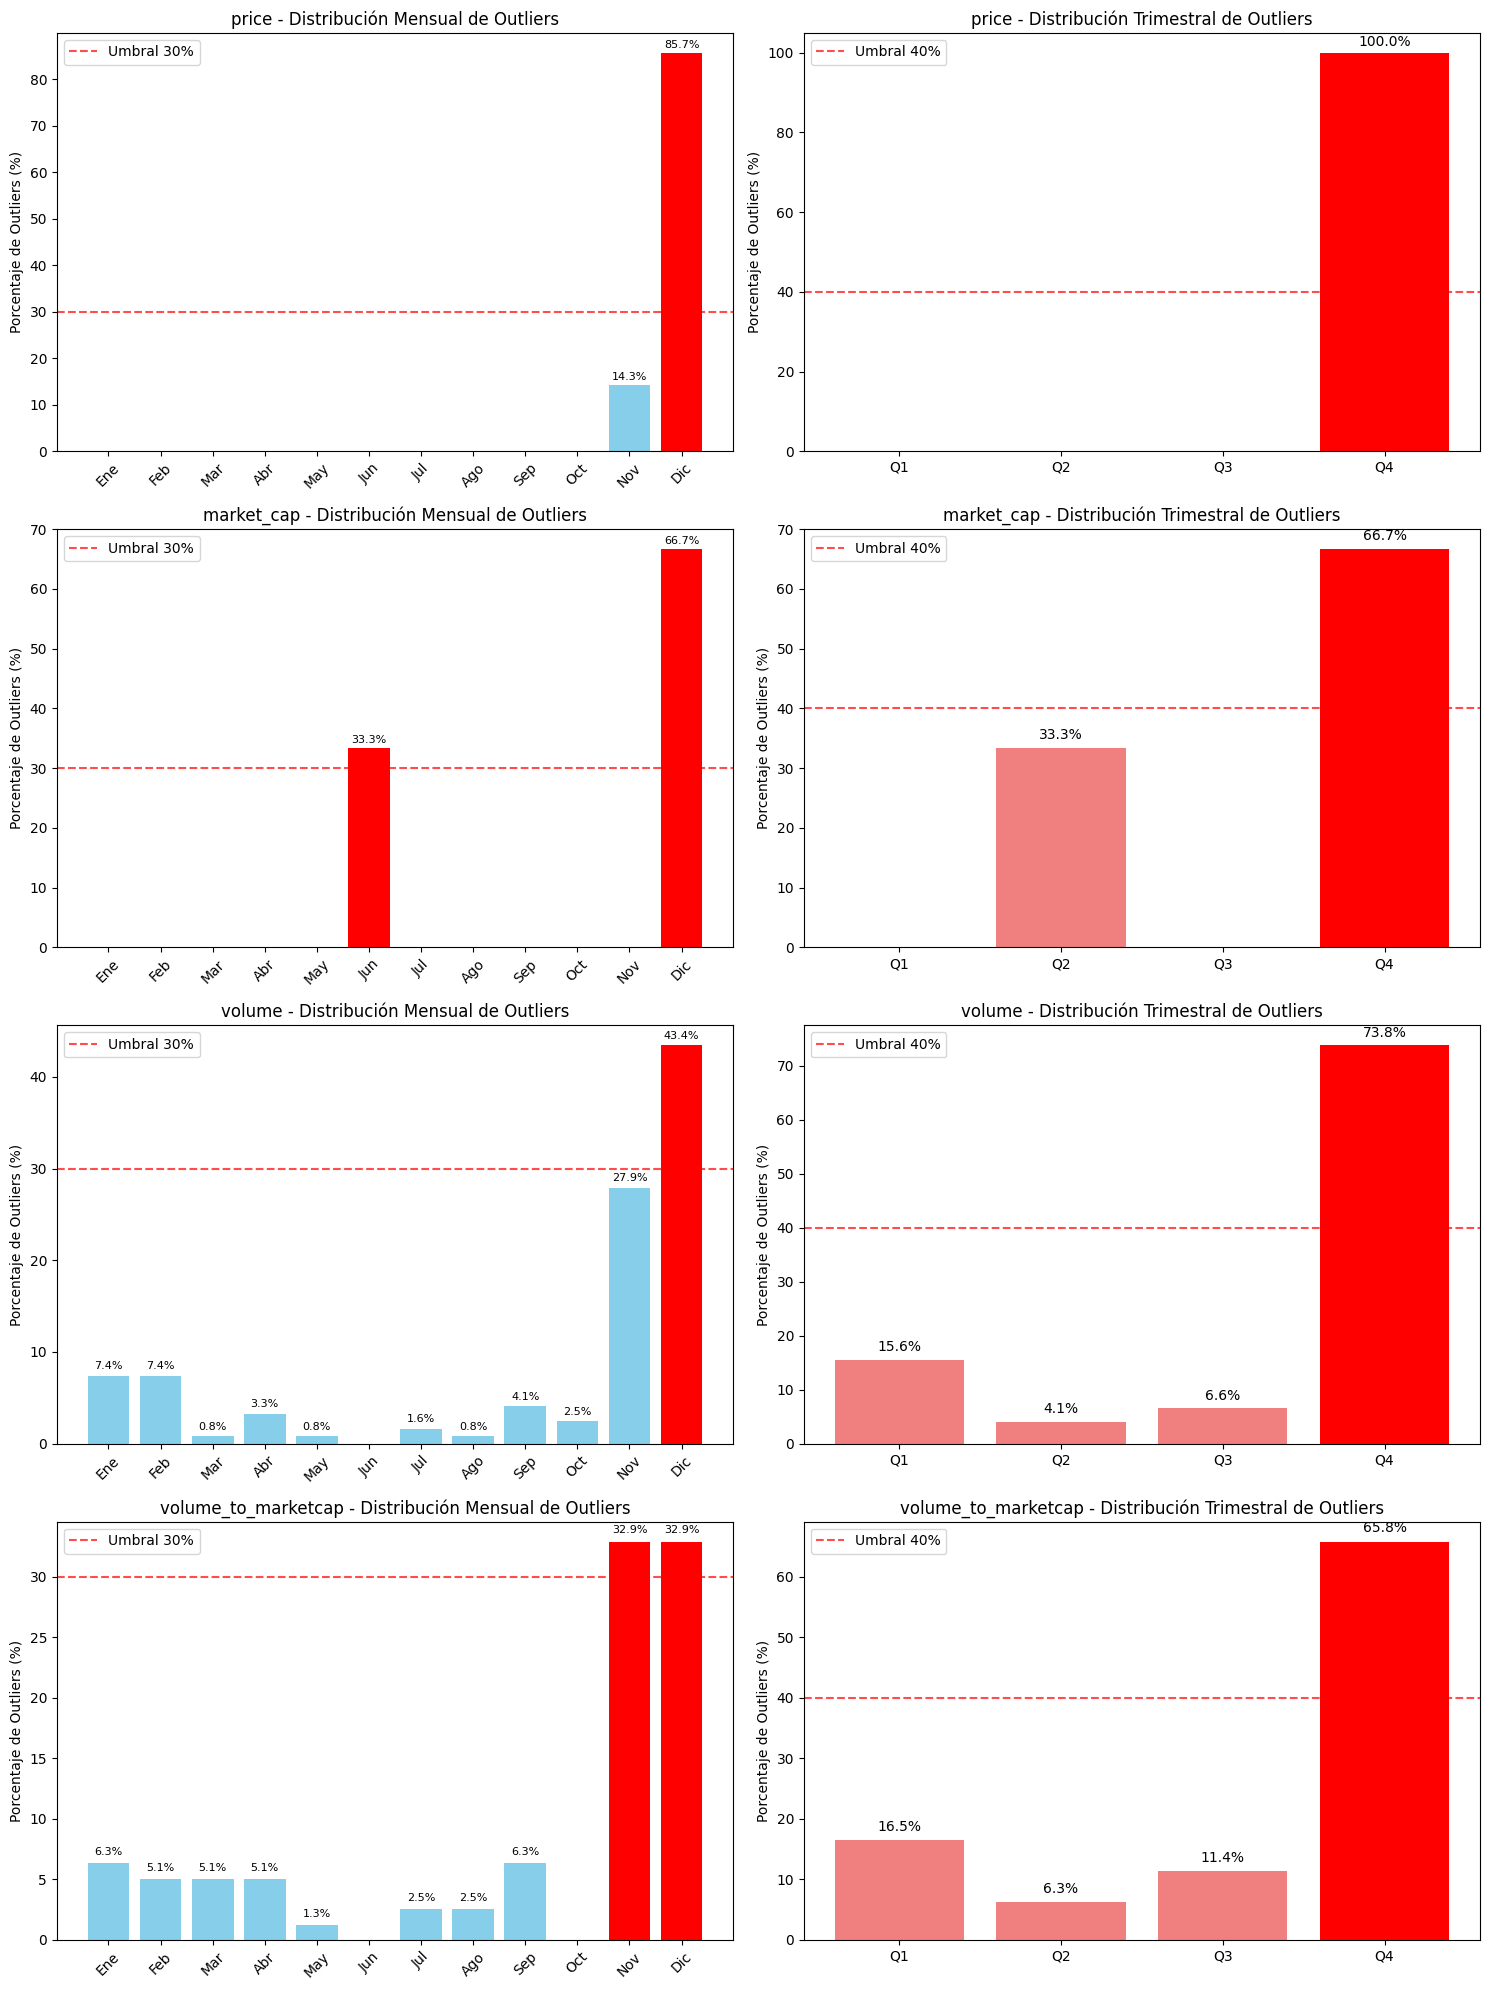

In [253]:
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

def plot_seasonal_outliers(data, results, variables_to_plot=None):
    """
    Crea visualizaciones de la distribución temporal de outliers
    """
    if variables_to_plot is None:
        variables_to_plot = [var for var in results.keys() if results[var]['is_seasonal']]
    
    if not variables_to_plot:
        print("No hay variables con estacionalidad para visualizar.")
        return
    
    # Configurar el estilo
    plt.style.use('default')
    
    # Crear subplots
    n_vars = len(variables_to_plot)
    fig, axes = plt.subplots(n_vars, 2, figsize=(15, 5*n_vars))
    
    if n_vars == 1:
        axes = axes.reshape(1, -1)
    
    month_names = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun',
                   'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']
    
    for i, var in enumerate(variables_to_plot):
        result = results[var]
        
        # Gráfico mensual
        monthly_data = [result['monthly_percentages'].get(month, 0) for month in range(1, 13)]
        bars1 = axes[i, 0].bar(month_names, monthly_data, 
                              color=['red' if x >= 30 else 'skyblue' for x in monthly_data])
        axes[i, 0].set_title(f'{var} - Distribución Mensual de Outliers')
        axes[i, 0].set_ylabel('Porcentaje de Outliers (%)')
        axes[i, 0].axhline(y=30, color='red', linestyle='--', alpha=0.7, label='Umbral 30%')
        axes[i, 0].legend()
        axes[i, 0].tick_params(axis='x', rotation=45)
        
        # Agregar valores encima de las barras
        for bar, value in zip(bars1, monthly_data):
            if value > 0:
                axes[i, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
                               f'{value:.1f}%', ha='center', va='bottom', fontsize=8)
        
        # Gráfico trimestral
        quarterly_data = [result['quarterly_percentages'].get(quarter, 0) for quarter in range(1, 5)]
        quarter_labels = ['Q1', 'Q2', 'Q3', 'Q4']
        bars2 = axes[i, 1].bar(quarter_labels, quarterly_data,
                              color=['red' if x >= 40 else 'lightcoral' for x in quarterly_data])
        axes[i, 1].set_title(f'{var} - Distribución Trimestral de Outliers')
        axes[i, 1].set_ylabel('Porcentaje de Outliers (%)')
        axes[i, 1].axhline(y=40, color='red', linestyle='--', alpha=0.7, label='Umbral 40%')
        axes[i, 1].legend()
        
        # Agregar valores encima de las barras
        for bar, value in zip(bars2, quarterly_data):
            if value > 0:
                axes[i, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
                               f'{value:.1f}%', ha='center', va='bottom', fontsize=10)
    
    plt.tight_layout()
    plt.show()

# Crear las visualizaciones
print("Creando visualizaciones de distribución temporal de outliers...")
plot_seasonal_outliers(eda_data, seasonal_analysis_results)

Creando diagramas de dispersión temporal para variables numéricas...


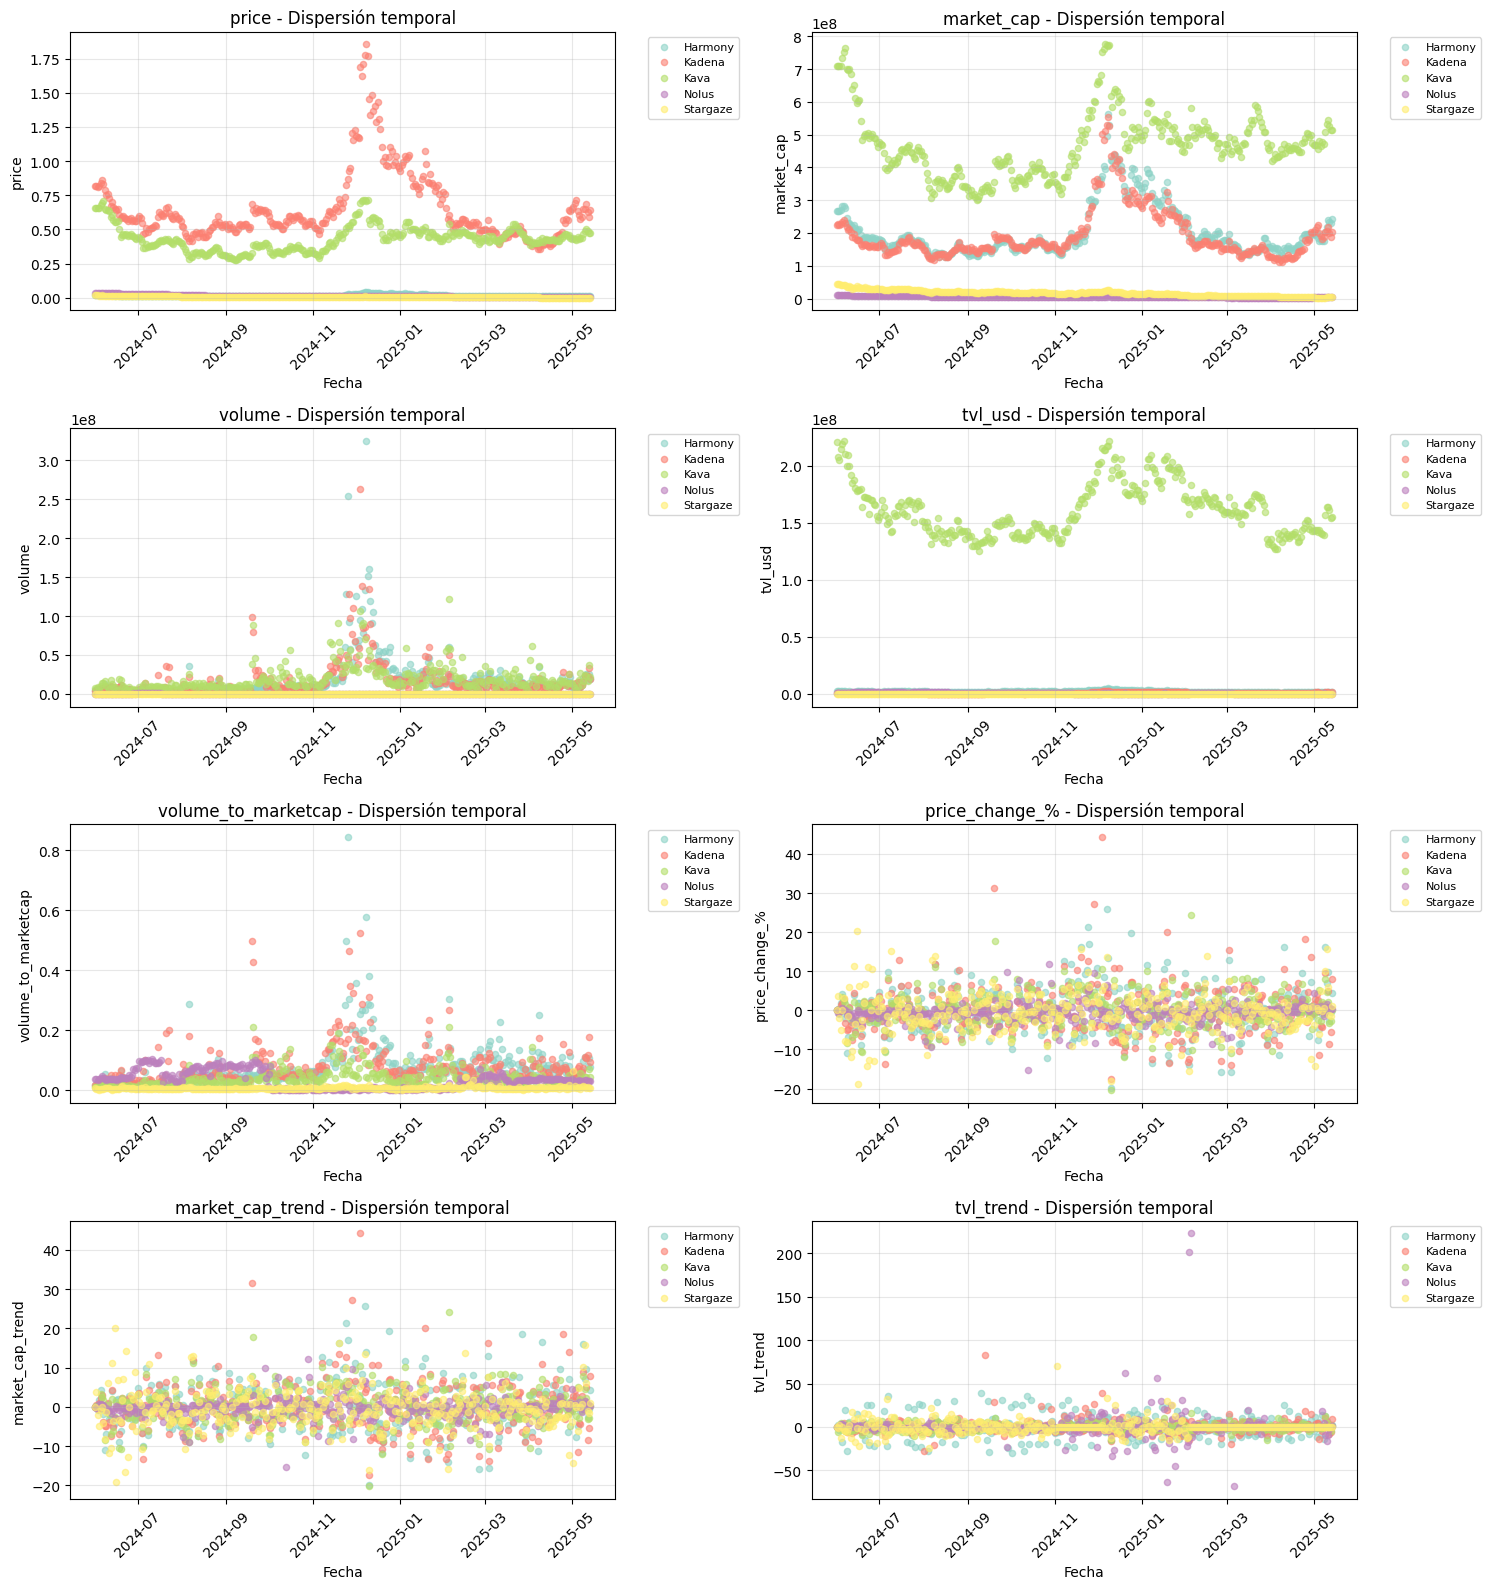

In [256]:
def plot_time_series_scatter(data, numeric_cols):
    """
    Crea diagramas de dispersión de cada variable numérica a lo largo del tiempo
    """
    cols_per_row = 2
    n = len(numeric_cols)
    rows = -(-n // cols_per_row)  # Ceiling division
    
    plt.figure(figsize=(15, rows * 4))
    
    for idx, col in enumerate(numeric_cols, 1):
        plt.subplot(rows, cols_per_row, idx)
        
        # Crear scatter plot con colores por token para mejor visualización
        tokens = data['name'].unique()
        colors = plt.cm.Set3(np.linspace(0, 1, len(tokens)))
        
        for token, color in zip(tokens, colors):
            token_data = data[data['name'] == token]
            plt.scatter(token_data['date'], token_data[col], 
                       alpha=0.6, s=20, label=token, color=color)
        
        plt.title(f'{col} - Dispersión temporal')
        plt.xlabel('Fecha')
        plt.ylabel(col)
        plt.xticks(rotation=45)
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
        plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Plotear las dispersiones temporales
print("Creando diagramas de dispersión temporal para variables numéricas...")
plot_time_series_scatter(eda_data, numeric_columns)

In [284]:
def create_seasonal_datasets(data, seasonal_results):
    """
    Crea datasets separados basándose en la estacionalidad de outliers
    Prioriza la división mensual sobre la trimestral
    """
    # Identificar todas las variables con estacionalidad
    seasonal_vars = [var for var, result in seasonal_results.items() if result['is_seasonal']]
    
    if not seasonal_vars:
        print("No se detectó estacionalidad. No es necesario dividir el dataset.")
        return None, None, {}
    
    print(f"Variables con estacionalidad detectada: {seasonal_vars}")
    
    # Recopilar todos los períodos dominantes, priorizando mensual
    dominant_months = set()
    dominant_quarters = set()
    
    # Primero verificar si hay estacionalidad mensual
    monthly_seasonal_vars = [var for var in seasonal_vars 
                            if seasonal_results[var]['is_seasonal_monthly']]
    
    if monthly_seasonal_vars:
        print(f"Variables con estacionalidad mensual: {monthly_seasonal_vars}")
        # Usar estacionalidad mensual
        for var in monthly_seasonal_vars:
            result = seasonal_results[var]
            dominant_months.add(result['dominant_month'])
        
        print(f"Meses dominantes identificados: {sorted(dominant_months)}")
        
        # Crear máscara basada en meses
        seasonal_mask = data['month'].isin(dominant_months)
        division_type = "mensual"
        
    else:
        # Si no hay estacionalidad mensual, usar trimestral
        quarterly_seasonal_vars = [var for var in seasonal_vars 
                                  if seasonal_results[var]['is_seasonal_quarterly']]
        
        print(f"Variables con estacionalidad trimestral: {quarterly_seasonal_vars}")
        
        for var in quarterly_seasonal_vars:
            result = seasonal_results[var]
            dominant_quarters.add(result['dominant_quarter'])
        
        print(f"Trimestres dominantes identificados: {sorted(dominant_quarters)}")
        
        # Crear máscara basada en trimestres
        seasonal_mask = data['quarter'].isin(dominant_quarters)
        division_type = "trimestral"
    
    # Crear los datasets
    seasonal_dataset = data[seasonal_mask].copy()
    non_seasonal_dataset = data[~seasonal_mask].copy()
    
    # Información sobre la división
    division_info = {
        'seasonal_vars': seasonal_vars,
        'dominant_months': list(dominant_months),
        'dominant_quarters': list(dominant_quarters),
        'division_type': division_type,
        'seasonal_size': len(seasonal_dataset),
        'non_seasonal_size': len(non_seasonal_dataset),
        'seasonal_percentage': len(seasonal_dataset) / len(data) * 100,
        'non_seasonal_percentage': len(non_seasonal_dataset) / len(data) * 100
    }
    
    return seasonal_dataset, non_seasonal_dataset, division_info

# Crear los datasets divididos priorizando división mensual
print("Creando datasets basados en estacionalidad de outliers (priorizando división mensual)...")
print("="*60)

seasonal_data, non_seasonal_data, division_info = create_seasonal_datasets(eda_data, seasonal_analysis_results)

if seasonal_data is not None:
    print(f"\n✓ DATASETS CREADOS EXITOSAMENTE")
    print(f"Tipo de división: {division_info['division_type'].upper()}")
    print(f"Dataset estacional: {division_info['seasonal_size']} registros ({division_info['seasonal_percentage']:.1f}%)")
    print(f"Dataset no estacional: {division_info['non_seasonal_size']} registros ({division_info['non_seasonal_percentage']:.1f}%)")
    
    print(f"\nCaracterísticas del período estacional:")
    if division_info['dominant_months']:
        month_names = {1: 'Enero', 2: 'Febrero', 3: 'Marzo', 4: 'Abril', 
                      5: 'Mayo', 6: 'Junio', 7: 'Julio', 8: 'Agosto',
                      9: 'Septiembre', 10: 'Octubre', 11: 'Noviembre', 12: 'Diciembre'}
        dominant_month_names = [month_names[m] for m in division_info['dominant_months']]
        print(f"  - Meses dominantes: {', '.join(dominant_month_names)}")
    
    if division_info['dominant_quarters'] and division_info['division_type'] == 'trimestral':
        print(f"  - Trimestres dominantes: Q{', Q'.join(map(str, division_info['dominant_quarters']))}")
    
    print(f"\nRango temporal del dataset estacional:")
    print(f"  - Desde: {seasonal_data['date'].min()}")
    print(f"  - Hasta: {seasonal_data['date'].max()}")
    
    print(f"\nRango temporal del dataset no estacional:")
    print(f"  - Desde: {non_seasonal_data['date'].min()}")
    print(f"  - Hasta: {non_seasonal_data['date'].max()}")
else:
    print("No se crearon datasets separados (no hay estacionalidad significativa)")

Creando datasets basados en estacionalidad de outliers (priorizando división mensual)...
Variables con estacionalidad detectada: ['price', 'market_cap', 'volume', 'volume_to_marketcap']
Variables con estacionalidad mensual: ['price', 'market_cap', 'volume', 'volume_to_marketcap']
Meses dominantes identificados: [np.int32(11), np.int32(12)]

✓ DATASETS CREADOS EXITOSAMENTE
Tipo de división: MENSUAL
Dataset estacional: 305 registros (17.5%)
Dataset no estacional: 1435 registros (82.5%)

Características del período estacional:
  - Meses dominantes: Noviembre, Diciembre

Rango temporal del dataset estacional:
  - Desde: 2024-11-01 00:00:00
  - Hasta: 2024-12-31 00:00:00

Rango temporal del dataset no estacional:
  - Desde: 2024-06-01 00:00:00
  - Hasta: 2025-05-14 00:00:00


In [255]:
# Guardar los datasets divididos
if seasonal_data is not None:
    # Definir las rutas de guardado
    seasonal_path = r"C:\Users\rosar\RufoEsEterno\MachineLearning\TP-Machine-Learning\data\seasonal_dataset.csv"
    non_seasonal_path = r"C:\Users\rosar\RufoEsEterno\MachineLearning\TP-Machine-Learning\data\non_seasonal_dataset.csv"
    
    # Guardar los datasets (sin las columnas auxiliares temporales)
    columns_to_save = [col for col in seasonal_data.columns if col not in ['year', 'month', 'quarter', 'month_name']]
    
    seasonal_data[columns_to_save].to_csv(seasonal_path, index=False)
    non_seasonal_data[columns_to_save].to_csv(non_seasonal_path, index=False)
    
    print(f"✓ Datasets guardados exitosamente:")
    print(f"  - Dataset estacional: {seasonal_path}")
    print(f"  - Dataset no estacional: {non_seasonal_path}")


print("="*80)

✓ Datasets guardados exitosamente:
  - Dataset estacional: C:\Users\rosar\RufoEsEterno\MachineLearning\TP-Machine-Learning\data\seasonal_dataset.csv
  - Dataset no estacional: C:\Users\rosar\RufoEsEterno\MachineLearning\TP-Machine-Learning\data\non_seasonal_dataset.csv
